# Tumor-coupling experiment — analysis & visualisation

This notebook reads the **archived simulation data** written by `tumor_coupling.py`
and reproduces everything that used to be baked into the run script:

* a colour-coded 2-D **GIF** of the flat sheet (faces by `cell_type`) + still frames,
* **tumor vs healthy** cell-population over time,
* **tumor size** (summed tumor face area) over time, and
* the **face-area overlap diagnostic** (smallest face areas over time).

The run's `outputs/history.hf5` is reopened with `HistoryHdf5.from_archive`, so you
can re-analyse without re-simulating, and re-run `tumor_coupling.py` without
disturbing earlier analysis.

Run from the repo's **`vivarium-tyssue` conda env** (needs ImageMagick `magick` on
PATH for the GIF).

## How the coupling works

The experiment couples a **non-spatial population ODE of a tumor** to a **continuous
vertex-model epithelium**: the ODE says how fast cells are being born and dying, and
that rate information is turned into discrete division / extrusion events on the mesh.

### Mechanics — vertex model

Cells are polygons $\alpha$ of area $A_\alpha$ and perimeter $P_\alpha$; junctions
$\langle ij\rangle$ have length $\ell_{ij}$ and line tension $\Lambda_{ij}$:

$$
E \;=\; \sum_{\alpha}\left[\frac{K_A}{2}\left(A_\alpha - A_{0,\alpha}\right)^2
      \;+\; \frac{K_P}{2}\left(P_\alpha - P_0\right)^2\right]
  \;+\; \frac{1}{2}\sum_{\langle ij\rangle}\Lambda_{ij}\,\ell_{ij},
\qquad
\eta\,\frac{\mathrm{d}\mathbf{r}_i}{\mathrm{d}t} = -\frac{\partial E}{\partial \mathbf{r}_i},
$$

integrated by forward Euler with step $\Delta t$. On this flat sheet the line
tension is off ($\Lambda_{ij}=0$), and the shape index
$p_0 = P_0/\sqrt{A_{0}} = 3.6$ sits below the $\sim 3.81$ rigidity transition, so the
tissue stays in the **solid / jammed** regime and cells hold compact shapes instead
of deforming into overlaps. The **preferred area $A_{0,\alpha}$ is per cell** — that
is the handle every discrete event pulls on.

### The tumor population model (COPASI)

BioModels `BIOMD0000000903` is a non-spatial system of ODEs for interacting cell
populations — healthy cells, tumor cells and cancer stem cells (with immune
compartments). For a state vector $\mathbf{y}$ and reaction fluxes $J_r(\mathbf{y})$
with stoichiometry $\nu_r$,

$$
\frac{\mathrm{d}\mathbf{y}}{\mathrm{d}t} \;=\; \sum_r \nu_r\, J_r(\mathbf{y}).
$$

It carries **no spatial information** — it only says how fast each population is being
created or removed. The experiment couples those *rates* to the mesh.

### Coupling the two clocks

Each solver step of length $\Delta t$, COPASI is integrated forward by $\alpha\,\Delta t$
of its own model time, so the tumor-model clock runs at $\alpha$ times the tyssue clock:

$$
\mathbf{y}(\tau + \alpha\,\Delta t) \;\leftarrow\; \mathrm{COPASI}\bigl(\mathbf{y}(\tau),\,\alpha\,\Delta t\bigr),
\qquad \alpha = \texttt{COPASI\_TIME}.
$$

$\alpha = 1$ runs them 1:1. ($\alpha < 1$ slows the ODE but also **delays** the
tumor-induction flux, which starves a small seed into extinction — so $\alpha$ is
kept at $1$.)

### From continuous flux to discrete mesh events

A continuous flux cannot fire a fraction of a cell, so each birth/death **channel**
$c$ keeps a fractional **accumulator** $\Phi_c$. Every step it grows by the scaled
flux; whenever it crosses $1$, an integer number of events fire and the remainder is
carried:

$$
\Phi_c \;\leftarrow\; \Phi_c + \max\bigl(J_c,\,0\bigr)\,s_c\,\Delta t,
\qquad
n_c = \left\lfloor \Phi_c \right\rfloor,
\qquad
\Phi_c \;\leftarrow\; \Phi_c - n_c,
$$

so channel $c$ fires at mean rate $J_c\,s_c$ events per unit tyssue time, where
$s_c = \texttt{SCALES}[c]$ maps the SBML flux magnitude (here $O(10^3\!-\!10^7)$) onto
the mesh. The $n_c$ selected cells are committed to a vertex-model event:

* **birth** $\rightarrow$ `cell_division` (the cell splits, the mesh gains a face),
* **death** $\rightarrow$ `apoptosis_extrusion` (the cell shrinks and is removed),
* **tumor induction** $\rightarrow$ `differentiation` of a cancer stem cell into a
  tumor cell (this is what turns the coupled births into a spreading tumor clone).

The tumor is seeded as a compact central **cancer-stem-cell** focus, mirroring the
SBML model's nonzero initial stem population. Stem cells self-renew through their own
births and commit their first cell to tumor (C$\rightarrow$T); the bulk tumor then
grows by dividing tumor cells, so a persistent purple stem core sits at the centre of
the spreading red clone.

### Executing an event — gradual growth

An event is **not** an instantaneous topology flip: a committed cell has its preferred
area ramped each solver step until its *actual* area crosses a threshold,

$$
\textbf{division:}\quad A_0(t+\Delta t) = A_0(t)\,(1 + g\,\Delta t),
\quad\text{split when } A > A_c^{\mathrm{div}},
$$
$$
\textbf{extrusion:}\quad A_0(t+\Delta t) = A_0(t)\,(1 - s\,\Delta t),
\quad\text{remove when } A < A_c^{\mathrm{ex}},
$$

with growth rate $g = \texttt{growth\_rate}$ and shrink rate $s = \texttt{shrink\_rate}$.

### Timescale coupling — why divisions don't overlap

Because the ramp is applied at the **real solver step**, $g$ is a true
per-tyssue-time rate: a cell inflates over $\tau_{\mathrm{grow}} = \ln 2 / g$. With
$g = 0.5$, $\tau_{\mathrm{grow}} \approx 1.4$ — about $4\times$ the sheet's mechanical
relaxation time $\tau_{\mathrm{mech}} \approx 0.36$ (measured by
`calibrate_timescale.py`). So the sheet fully relaxes around each division before the
next one fires, and the **minimum face area stays above $0$** (the overlap diagnostic
below). The `SCALES` set the birth : death balance (the tumor grows net-positive) and the
overall event rate, chosen for fewer, better-spaced divisions.

### Parameters

| symbol | meaning | code / value |
|---|---|---|
| $K_A,\;A_0$ | area elasticity, preferred area | `area_elasticity` = 1, `prefered_area` = 1 |
| $K_P,\;P_0$ | perimeter elasticity, preferred perimeter | `perimeter_elasticity` = 0.1, `prefered_perimeter` = 3.6 |
| $\eta$ | vertex friction | `viscosity` = 1 |
| $\Lambda$ | line tension (off on the flat sheet) | `line_tension` = 0 |
| $\alpha$ | tumor clock / tyssue clock | `COPASI_TIME` = 1.0 |
| $s_c$ | flux $\rightarrow$ event scales | `SCALES` |
| $g,\;A_c^{\mathrm{div}}$ | growth rate, division area | `growth_rate` = 0.5, `division_crit` = 2.0 |
| $s,\;A_c^{\mathrm{ex}}$ | shrink rate, extrusion area | `shrink_rate` = 0.5, `apoptosis_crit` = 2.0 |
| seed | central cancer-stem-cell focus | `{"stem": 6}` |
| $\Delta t,\;T$ | solver step, total time | `TUMOR_DT` = 0.01, `TUMOR_TF` = 300 |

The exact COPASI reaction keys are `BIRTH_FLUXES` / `DEATH_FLUXES`; the flux $J_c$ for
each channel is read from the SBML model every step.

In [1]:
from __future__ import annotations
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from IPython.display import Image, display

# Simulation config is the single source of truth — import it from the sim script.
import tumor_coupling as sim
from tumor_coupling import (
    OUT_DIR, COORDS_2D, SCALES, COPASI_TIME, TUMOR_TF, TUMOR_DT,
    BIRTH_FLUXES, DEATH_FLUXES,
)

sys.path.insert(0, str(sim.REPO))   # so vivarium_tyssue.draw / tyssue import cleanly
from tyssue.core.history import HistoryHdf5

# --- visualisation / analysis constants (were in the old monolithic script) ---
FIG_DPI = 300          # publication-quality raster resolution for stills / plots
GIF_DPI = 120          # animation (kept lower — many frames)
NUM_GIF_FRAMES = 120
N_STILLS = 6

# Face palette by cell_type (matches vivarium_tyssue.visualizations.tissue_gif).
CELL_TYPE_COLORS = {
    "healthy": "#4a90d9",    # blue — normal epithelium
    "tumor": "#c0392b",      # red — tumor cells
    "stem": "#8e44ad",       # purple — cancer stem cells
    "dead": "#2b2b2b",       # near-black — cells killed under SBML control
    "dividing": "#feeda3",   # yellow — mid-division (transient)
    "extruding": "#000000",  # black — mid-extrusion (transient)
}
# Cell types drawn in the population-over-time analysis, in legend order.
POP_TYPES = ["healthy", "tumor", "stem", "dead"]
# Legend entries always shown, even on frames with none present, so e.g. "dividing"
# stays in the key across the whole gif. Others are added only if they appear.
ALWAYS_LEGEND = ("healthy", "tumor", "dividing")

print("archive:", OUT_DIR / "history.hf5")

archive: /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/tumor_coupling/outputs/history.hf5


## The composite bigraph

The experiment is a two-process `process_bigraph` **composite**: the `EulerSolver`
process (`Tyssue`) integrating the flat-sheet vertex model, and `TumorCoupling`,
which owns the COPASI/SBML population ODE internally, turns its per-reaction fluxes
into discrete division / extrusion events, and hands them over as **behaviours**.
The two only meet at the shared **stores** — `TumorCoupling` reads `Tissue State` (the
tyssue `vert` / `edge` / `face` / `cell` dataframes) and `global_time` and writes
`Behaviors`; the solver executes them and reports back through `Tissue State` and
`Network Changed`.

`bigraph_viz` draws the wiring below in the style of `Notebooks/simulation_walkthrough.ipynb`, with the manuscript palette:
**processes are boxes in peach / pink**, **stores are circles in light blue**
(defined once in `Experiments/bigraph_style.py`). Every spec comes straight
from the simulation script, so the diagram cannot drift from what was run;
the PNGs are written to `outputs/bigraphs/`.

(`TumorCoupling` also *declares* per-species count / flux output ports that this spec
leaves unwired; they are hidden here — pass `show_unwired_ports=True` to draw them.)

In [2]:
sys.path.insert(0, str(sim.REPO / "Experiments"))   # shared bigraph palette
from bigraph_style import plot_experiment_bigraph
from vivarium_tyssue.core import build_core

core = build_core()                    # the same core the simulation runs on
spec = sim.build_tumor_spec(sim.ensure_dataset(sim.FLAT_DATASET),
                            sim.ensure_dataset(sim.SBML_MODEL))
plot_experiment_bigraph(spec, core=core, filename="tumor_coupling_bigraph",
                        out_dir=OUT_DIR / "bigraphs")

skipping `process_bigraph.server.rest` (missing optional dep `fastapi_utils`)


module `pbg_emitters.xarray_emitter` not found during dynamic import


wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/tumor_coupling/outputs/bigraphs/tumor_coupling_bigraph.png


## Loading an archived history

Same helper as the other experiment notebooks: reopen the archive with
`HistoryHdf5.from_archive` for drawing, read the full stacked dataframes from the
HDF5 store for analysis, and rebuild each retrieved frame from those stacked tables
(restoring the per-frame topological index from the `vert` / `edge` / `face`
columns) so drawing and geometry updates line up.

In [3]:
class LoadedHistory:
    # Reopened archive with the same surface as an in-memory tyssue History:
    # .time_stamps, .retrieve(t) (drawing), .datasets (full stacked dfs, analysis).
    def __init__(self, path):
        self._h = HistoryHdf5.from_archive(str(path))
        self._sheet = self._h.sheet
        with pd.HDFStore(str(path), "r") as store:
            self.datasets = {k.strip("/"): store.select(k) for k in store.keys()}
        self._times = np.array(sorted(self.datasets["vert"]["time"].unique()))

    @property
    def time_stamps(self):
        return self._times

    def retrieve(self, t):
        # Rebuild a sheet at the nearest recorded time from the stacked datasets,
        # restoring each element's per-frame index from its vert/edge/face column.
        t = self._times[int(np.argmin(np.abs(self._times - t)))]
        sheet_datasets = {}
        for elem, df in self.datasets.items():
            sub = df[df["time"] == t]
            if elem in sub.columns:
                sub = sub.set_index(elem)
                sub.index.name = elem
            sheet_datasets[elem] = sub
        sheet = type(self._sheet)(f"{self._sheet.identifier}_{t:04.3f}",
                                  sheet_datasets, self._sheet.specs)
        sheet.coords = self._sheet.coords
        return sheet

    def update_datasets(self):
        pass

    def __getattr__(self, name):
        return getattr(self._h, name)

## Drawing — 2-D flat sheet, faces by cell type

Faces are coloured by `cell_type`: **healthy = blue**, **tumor = red**,
**stem = purple**, transient **dividing = yellow** / **extruding = black**. Axis
limits are fixed from the first frame so the sheet doesn't rescale as it grows, and
the legend is keyed on the whole run so it stays identical on every frame.

In [4]:
def _face_color(sheet):
    # (Nf, 4) RGBA per face, coloured by cell_type.
    return np.array([
        mcolors.to_rgba(CELL_TYPE_COLORS.get(ct, "#cccccc"))
        for ct in sheet.face_df["cell_type"]
    ])


def _legend_handles(types):
    keys = [k for k in CELL_TYPE_COLORS if k in set(types)]
    return [Patch(facecolor=CELL_TYPE_COLORS[k], edgecolor="#808080", label=k) for k in keys]


def _run_legend_types(history, times):
    # Cell types to key the whole animation on: the union of types seen across the
    # run plus the always-shown core — so the legend is identical on every frame.
    seen = set(ALWAYS_LEGEND)
    for t in times:
        seen.update(map(str, history.retrieve(t).face_df["cell_type"].unique()))
    return [k for k in CELL_TYPE_COLORS if k in seen]


def _frame_limits(history, times):
    # Fixed (min, max) per-axis limits from the first frame, with a 5% margin.
    sheet0 = history.retrieve(times[0])
    bounds = sheet0.vert_df[COORDS_2D].describe().loc[["min", "max"]]
    margin = (bounds.loc["max"] - bounds.loc["min"]).max() * 0.05
    return {c: (bounds.loc["min", c] - margin, bounds.loc["max", c] + margin) for c in COORDS_2D}


def _draw_frame(sheet, title, lims, legend_types):
    # Draw one flat-sheet frame (faces by cell_type). Returns Figure or None.
    from tyssue.draw import sheet_view
    try:
        fig, ax = plt.subplots(figsize=(6.6, 5.0))
        sheet_view(
            sheet, coords=COORDS_2D, ax=ax,
            face={"visible": True, "color": _face_color(sheet), "alpha": 1.0},
            edge={"visible": True, "color": "#808080", "width": 0.8},
        )
        ax.set_aspect("equal")
        ax.set_xlim(*lims["x"]); ax.set_ylim(*lims["y"])
        ax.set_title(title, fontsize=10)
        ax.legend(handles=_legend_handles(legend_types), loc="upper left",
                  bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=8)
    except Exception as exc:  # noqa: BLE001
        print(f"frame {title} failed ({type(exc).__name__}: {exc}); skipping")
        plt.close("all")
        return None
    return fig


def save_gif(history, out_path: Path):
    times = list(history.time_stamps)
    if not times:
        return
    lims = _frame_limits(history, times)
    idx = np.unique(np.round(np.linspace(0, len(times) - 1,
                                         min(NUM_GIF_FRAMES, len(times)))).astype(int))
    legend_types = _run_legend_types(history, [times[int(i)] for i in idx])
    tmp = Path(tempfile.mkdtemp())
    n = 0
    try:
        for i in idx:
            t = times[int(i)]
            fig = _draw_frame(history.retrieve(t), f"t = {float(t):.1f}", lims, legend_types)
            if fig is None:
                continue
            fig.savefig(tmp / f"frame_{n:04d}.png", dpi=GIF_DPI, bbox_inches="tight")
            plt.close(fig); n += 1
        if n == 0:
            print(f"no renderable frames for {out_path.name}; skipping GIF"); return
        subprocess.run(["magick", "-delay", "12", "-loop", "0",
                        (tmp / "frame_*.png").as_posix(), str(out_path)], check=True)
        print(f"  wrote {out_path.name} ({n} frames)")
    finally:
        shutil.rmtree(tmp, ignore_errors=True)


def save_stills(history, out_dir: Path):
    times = list(history.time_stamps)
    if not times:
        return
    lims = _frame_limits(history, times)
    legend_types = _run_legend_types(history, times)
    for frac in np.linspace(0.0, 1.0, N_STILLS):
        t = times[int(round(frac * (len(times) - 1)))]
        fig = _draw_frame(history.retrieve(t), f"t = {float(t):.1f}", lims, legend_types)
        if fig is None:
            continue
        fig.savefig(out_dir / f"still_t{float(t):06.1f}.png", dpi=FIG_DPI, bbox_inches="tight")
        plt.close(fig)

## Analysis

Three complementary read-outs of the coupled run, all taken from the **mesh history**
(not the coupling's scalar `*_count` stores, which accumulate additively across steps
— a process-bigraph `map[float]` quirk — so the mesh is the reliable source for
instantaneous counts):

1. **Population over time** — $N$ of each `cell_type` vs $t$: the seeded tumor clone
   expands while the healthy population is displaced.
2. **Tumor size (area) over time** — the summed face area of all tumor cells: captures
   both proliferation (more faces) and per-cell growth (each face inflating toward
   $A_0$ before it divides), unlike the raw count.
3. **Overlap diagnostic** — the minimum / 5th-percentile face area vs $t$. If
   divisions outran mechanical relaxation, freshly-split faces would collapse toward
   zero area; with the timescale coupling ($\tau_{\mathrm{grow}} \approx 4\,\tau_{\mathrm{mech}}$)
   these floors stay comfortably above $0$.

In [5]:
def population_over_time(history) -> pd.DataFrame:
    # Count of each cell type at every recorded timepoint (wide: time x types).
    face = history.datasets["face"]
    df = face[face["is_alive"] > 0] if "is_alive" in face.columns else face
    counts = df.groupby(["time", "cell_type"]).size().unstack(fill_value=0)
    return counts.reindex(sorted(counts.index)).reset_index()


def plot_population_over_time(counts: pd.DataFrame, out_path: Path):
    fig, ax = plt.subplots(figsize=(8.0, 4.4))
    types = [t for t in POP_TYPES if t in counts.columns]
    for t in types:
        ax.plot(counts["time"], counts[t].to_numpy(), "-", linewidth=1.9,
                color=CELL_TYPE_COLORS[t], label=t)
    # Transient states (a cell mid-division / mid-extrusion) as thin reference lines.
    for t in ("dividing", "extruding"):
        if t in counts.columns and counts[t].to_numpy().max() > 0:
            ax.plot(counts["time"], counts[t].to_numpy(), ":", linewidth=1.0,
                    color=CELL_TYPE_COLORS[t], label=t, alpha=0.8)
    total = counts[[c for c in counts.columns if c != "time"]].sum(axis=1)
    ax.plot(counts["time"], total.to_numpy(), "--", linewidth=1.3,
            color="#555555", label="total (all types)")
    ax.set_xlabel(r"$t$"); ax.set_ylabel(r"$N$")
    ax.set_title("Tumor coupling: tumor vs healthy cell population over time", fontsize=11)
    ax.margins(x=0); ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=9)
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()


def tumor_area_over_time(history) -> pd.DataFrame:
    # Total tumor size: summed face `area` of all tumor cells (+ total area, fraction).
    face = history.datasets["face"]
    df = face[face["is_alive"] > 0] if "is_alive" in face.columns else face
    total = df.groupby("time")["area"].sum()
    tumor = (df[df["cell_type"] == "tumor"].groupby("time")["area"].sum()
             .reindex(total.index, fill_value=0.0))
    out = pd.DataFrame({"time": total.index, "tumor_area": tumor.to_numpy(),
                        "total_area": total.to_numpy()})
    out["tumor_area_fraction"] = out["tumor_area"] / out["total_area"].where(out["total_area"] > 0)
    return out.reset_index(drop=True)


def plot_tumor_area_over_time(area: pd.DataFrame, out_path: Path):
    fig, ax = plt.subplots(figsize=(8.0, 4.4))
    ax.fill_between(area["time"], area["tumor_area"], color=CELL_TYPE_COLORS["tumor"],
                    alpha=0.25, linewidth=0)
    ax.plot(area["time"], area["tumor_area"], "-", linewidth=2.0,
            color=CELL_TYPE_COLORS["tumor"], label=r"tumor area ($\sum$ face area)")
    ax.plot(area["time"], area["total_area"], "--", linewidth=1.3,
            color="#555555", label="total tissue area")
    ax.set_xlabel(r"$t$"); ax.set_ylabel(r"area (mesh units$^2$)")
    ax.set_title("Tumor coupling: tumor size (area) over time", fontsize=11)
    ax.margins(x=0); ax.grid(True, alpha=0.25, linewidth=0.6)

    ax2 = ax.twinx()   # tumor area as a fraction of the whole sheet
    ax2.plot(area["time"], 100.0 * area["tumor_area_fraction"], ":", linewidth=1.6,
             color="#8e44ad", label="tumor area fraction")
    ax2.set_ylabel("tumor area fraction (%)", color="#8e44ad")
    ax2.tick_params(axis="y", labelcolor="#8e44ad"); ax2.set_ylim(bottom=0)

    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [ln.get_label() for ln in lines],
              loc="upper left", bbox_to_anchor=(1.08, 1.0), frameon=False, fontsize=9)
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()


def face_area_floor_over_time(history) -> pd.DataFrame:
    # Smallest face areas at every recorded timepoint (overlap diagnostic).
    face = history.datasets["face"]
    df = face[face["is_alive"] > 0] if "is_alive" in face.columns else face
    g = df.groupby("time")["area"]
    return pd.DataFrame({
        "time": sorted(df["time"].unique()),
        "min_area": g.min().to_numpy(),
        "p5_area": g.quantile(0.05).to_numpy(),
        "median_area": g.median().to_numpy(),
    })


def plot_face_area_floor(area: pd.DataFrame, out_path: Path):
    fig, ax = plt.subplots(figsize=(8.0, 4.4))
    ax.plot(area["time"], area["median_area"], "-", linewidth=1.6,
            color="#4a90d9", label="median face area")
    ax.plot(area["time"], area["p5_area"], "-", linewidth=1.8,
            color="#e67e22", label="5th-percentile face area")
    ax.plot(area["time"], area["min_area"], "-", linewidth=1.8,
            color="#c0392b", label="minimum face area")
    ax.axhline(0.0, color="#000000", linewidth=0.8)
    ax.set_xlabel(r"$t$"); ax.set_ylabel(r"face area (mesh units$^2$)")
    ax.set_title("Tumor coupling: smallest face areas over time (overlap check)", fontsize=11)
    ax.set_ylim(bottom=min(0.0, float(area["min_area"].min())))
    ax.margins(x=0); ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=9)
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()

## Run — GIF, stills & analyses

Set `MAKE_GIF = False` to skip the (slow) animation while iterating on the plots.

loaded 2000 frames


  wrote tumor.gif (120 frames)


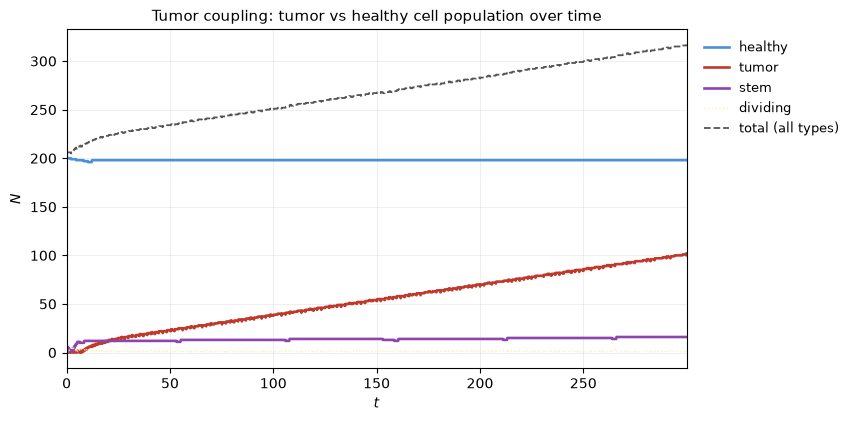

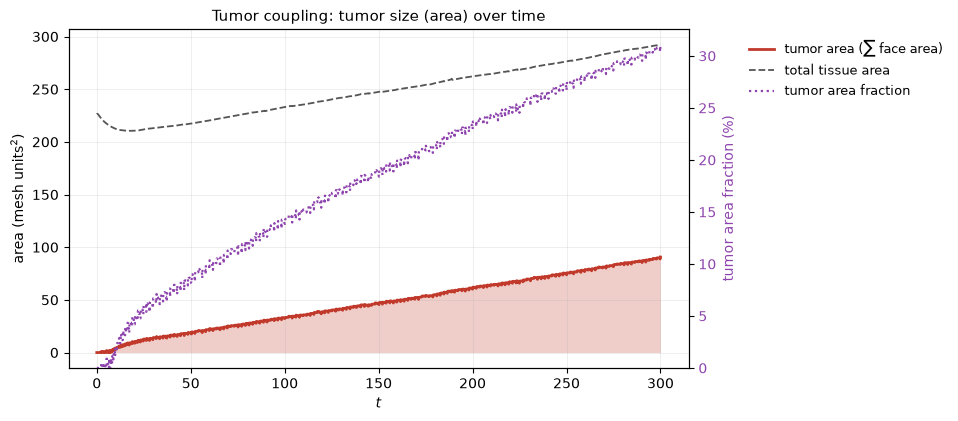

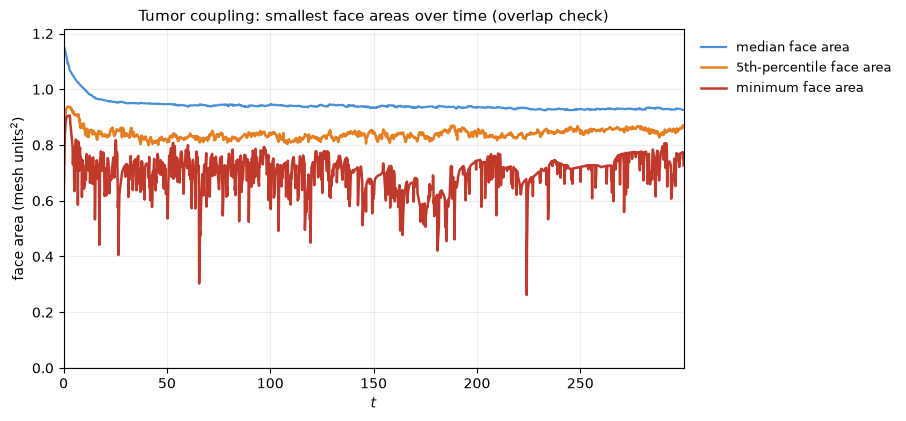

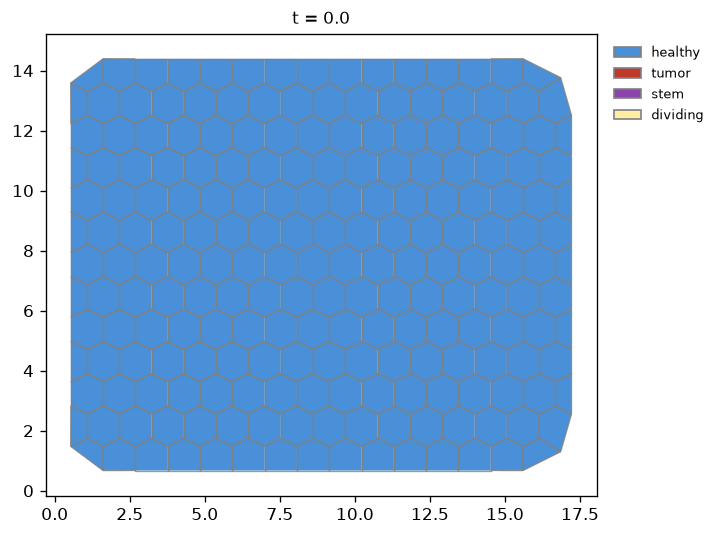

[tumor] population start {'healthy': 206, 'tumor': 0, 'stem': 0} -> end {'healthy': 198, 'tumor': 102, 'stem': 16}
[tumor] tumor area 0.00 -> 90.71 (31.0% of tissue)
[tumor] smallest face area (overlap check): min 0.262, 5th-pct floor 0.587 (both should stay > 0)


In [6]:
MAKE_GIF = True

hist_path = OUT_DIR / "history.hf5"
if not hist_path.exists():
    print("no archive — run `python tumor_coupling.py` first")
else:
    hist = LoadedHistory(hist_path)
    print(f"loaded {len(list(hist.time_stamps))} frames")

    if MAKE_GIF:
        save_gif(hist, OUT_DIR / "tumor.gif")
    save_stills(hist, OUT_DIR)

    counts = population_over_time(hist)
    counts.to_csv(OUT_DIR / "population_over_time.csv", index=False)
    plot_population_over_time(counts, OUT_DIR / "population_over_time.png")

    area = tumor_area_over_time(hist)
    area.to_csv(OUT_DIR / "tumor_area_over_time.csv", index=False)
    plot_tumor_area_over_time(area, OUT_DIR / "tumor_area_over_time.png")

    floor = face_area_floor_over_time(hist)
    floor.to_csv(OUT_DIR / "face_area_floor_over_time.csv", index=False)
    plot_face_area_floor(floor, OUT_DIR / "face_area_floor_over_time.png")

    if (OUT_DIR / "tumor.gif").exists():
        display(Image(filename=str(OUT_DIR / "tumor.gif")))

    start, end = counts.iloc[0], counts.iloc[-1]
    fmt = lambda row: {t: int(row[t]) for t in POP_TYPES if t in counts.columns}
    print(f"[tumor] population start {fmt(start)} -> end {fmt(end)}")
    print(f"[tumor] tumor area {area['tumor_area'].iloc[0]:.2f} -> "
          f"{area['tumor_area'].iloc[-1]:.2f} "
          f"({100 * area['tumor_area_fraction'].iloc[-1]:.1f}% of tissue)")
    print(f"[tumor] smallest face area (overlap check): min {floor['min_area'].min():.3f}, "
          f"5th-pct floor {floor['p5_area'].min():.3f} (both should stay > 0)")